In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

D:\Users\Boris\AppData\Local\Temp\ipykernel_21628\3538350959.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [1]:
from calc_tepl import Tepl

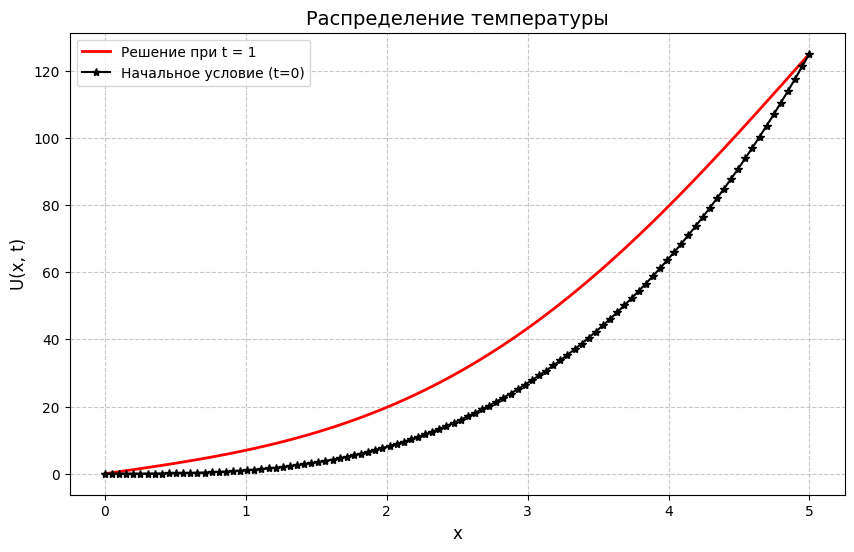

In [2]:
model = Tepl(a=1.0, x1=0.0, x2=5.0, t=1)
model.set_initial_condition(B=1.0, Nx=100)
model.calc_temp(Nt=1000)
model.plot_solution(B=1.0)

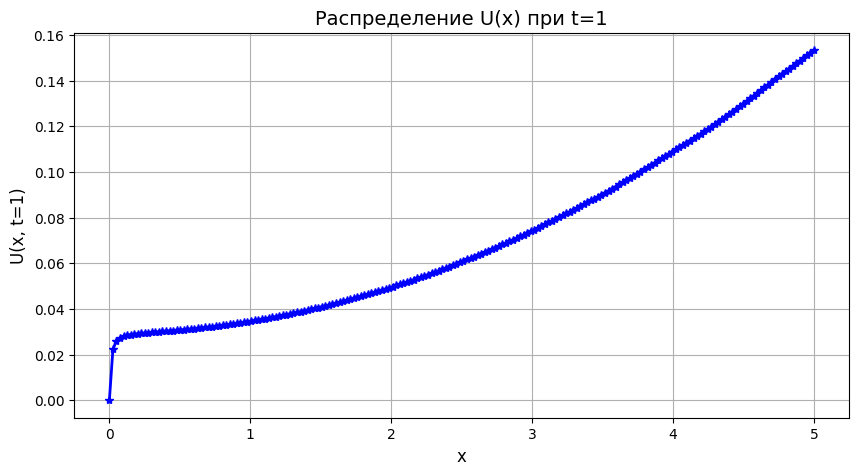

In [5]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

a = 1.0
B = 1.0


# Решение ОДУ
def ode_system(z, y):
    f, fp = y
    df_dz = fp

    dfp_dz = -fp * (6 / z + 0.5 * z) - (6 / (z ** 2)) * f
    return [df_dz, dfp_dz]


z_max, z_min = 0.01, 10
z_eval = np.linspace(z_max, z_min, 1000)
sol = solve_ivp(ode_system, [z_max, z_min], [1.0, 0.0], t_eval=z_eval)

# [1.0, 0.0]
f_interp = interp1d(sol.t[::-1], sol.y[0][::-1], kind='cubic', fill_value="extrapolate")

# Фиксируем время t и строим U(x)
t_fixed = 1
x_vals = np.linspace(0, 5, 200)
z_vals = x_vals / (a * np.sqrt(t_fixed))
U_vals = B * x_vals ** 2 * f_interp(z_vals)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, U_vals * 100, 'b-*', linewidth=2)
plt.xlabel('x', fontsize=12)
plt.ylabel(f'U(x, t={t_fixed})', fontsize=12)
plt.title(f'Распределение U(x) при t={t_fixed}', fontsize=14)
plt.grid(True)
plt.show()

$$
U(x,t) = \frac{1}{2a\sqrt{\pi t}} \int_{-\infty}^{\infty} \varphi_{ext}(\xi) e^{-\frac{(x-\xi)^2}{4a^2t}} d\xi
$$

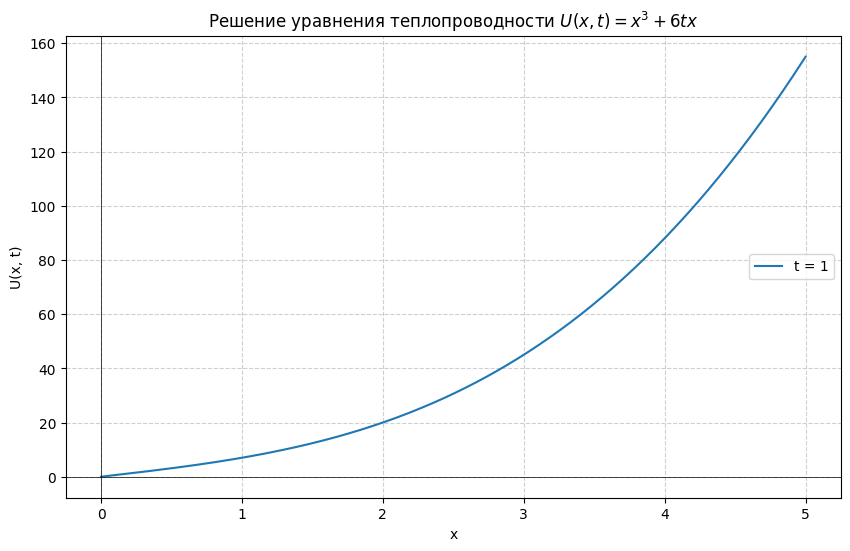

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 5, 400)
t_values = [1]

plt.figure(figsize=(10, 6))
for t in t_values:
    U = x ** 3 + 6 * t * x
    plt.plot(x, U, label=f"t = {t}")

plt.xlabel("x")
plt.ylabel("U(x, t)")
plt.title("Решение уравнения теплопроводности $U(x, t) = x^3 + 6t x$")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

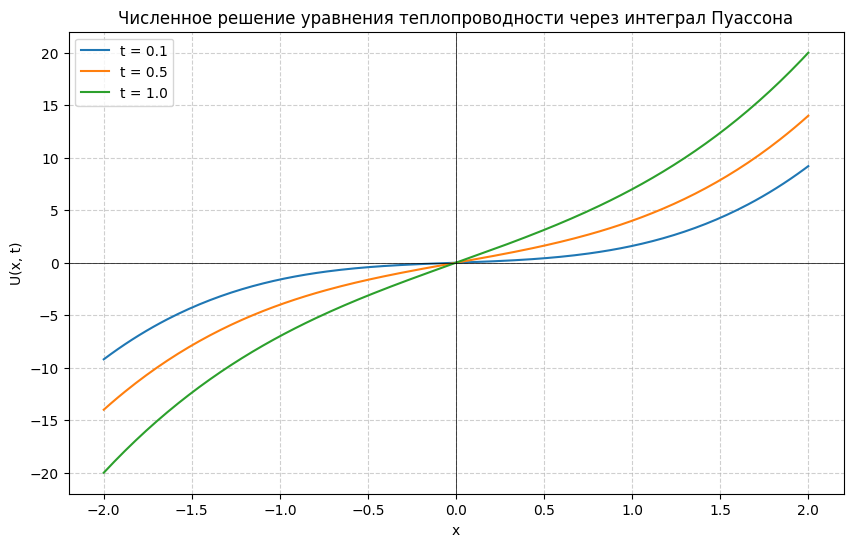

In [7]:
import numpy as np
import matplotlib.pyplot as plt

B = 1
a = 1
t_values = [0.1, 0.5, 1.0]  
x = np.linspace(-2, 2, 200)  


def phi(xi):
    return B * xi ** 3


# Численное вычисление интеграла Пуассона
def poisson_integral(x, t, a, dxi=0.01):
    xi = np.arange(-10, 10 + dxi, dxi)
    integrand = phi(xi) * np.exp(-(x - xi) ** 2 / (4 * a ** 2 * t))
    integral = np.sum(integrand) * dxi
    return integral / (2 * a * np.sqrt(np.pi * t))


# Вычисляем U(x, t) для разных t
U_values = {}
for t in t_values:
    U = [poisson_integral(xi, t, a) for xi in x]
    U_values[t] = U

# Построение графиков
plt.figure(figsize=(10, 6))
for t in t_values:
    plt.plot(x, U_values[t], label=f"t = {t}")

plt.xlabel("x")
plt.ylabel("U(x, t)")
plt.title("Численное решение уравнения теплопроводности через интеграл Пуассона")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()